# Лабораторная работа «Реконструкция текста по данным»

## 0. Подготовка окружения

In [2]:
!pip install pymorphy3 wordcloud scikit-learn matplotlib
import re
import os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 6.5 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 9.5 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 8.5 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 8.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.4 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.8/37.3 MB 9.7 MB/s eta 0:00:04
   --- ------------------------------------ 3.7/37.3 MB 9.4 MB/s eta 0:00:04
   ------ --------------------------------- 5.8/37.3 MB 9.7 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/37.3 MB 7.7 MB/s eta 0:00:05
   ------ --------------------------------- 6.3/37.3 MB 6.8 MB/s eta 0:00:05
   -------- -----------

## 1. Чтение и предобработка

Файл 1.txt напечатан в дореформенной орфографии. Также в начале файла есть посвящение, оглавление и эпистолярная рамка — их можно либо отделить, либо проанализировать вместе с основным повествованием.

In [3]:
PATH = "1.txt"
with open(PATH, encoding="utf-8") as f:
    raw = f.read()
text = raw.replace("\r", "")
print(f"Длина исходного текста: {len(raw):,} символов")
print(f"Первые 200 символов:\n{repr(text[:200])}")

Длина исходного текста: 217,923 символов
Первые 200 символов:
'НЯНЮШКАМЪ\nи\nМАМУШКАМЪ\nблагодушнѣйше посвящаетъ\n\nБезлестный почитателъ ихъ\nВ. Б.\n\n  \nОГЛАВЛЕНІЕ.\n\n   Благодушнѣйшее посвященіе сей книги Нянюшкамъ и Мамушкамъ\n   Письмо ЛЮБОВѢДА къ СЛОВОХОТУ, въ которо'


In [4]:
def normalize_pre_reform(s):
    table = {"ѣ": "е", "Ѣ": "Е",
             "і": "и", "І": "И",
             "ѳ": "ф", "Ѳ": "Ф",
             "ѵ": "и", "Ѵ": "И"}
    for k, v in table.items():
        s = s.replace(k, v)
    # Убираем твёрдый знак на конце слова
    s = re.sub(r"ъ\b", "", s)
    return s

text_modern = normalize_pre_reform(text)
print("После нормализации (фрагмент):")
print(text_modern[:300])

После нормализации (фрагмент):
НЯНЮШКАМЪ
и
МАМУШКАМЪ
благодушнейше посвящает

Безлестный почитател их
В. Б.

  
ОГЛАВЛЕНИЕ.

   Благодушнейшее посвящение сей книги Нянюшкам и Мамушкам
   Письмо ЛЮБОВЕДА к СЛОВОХОТУ, в котором с восхищением описывая распространившееся ныне повсюду просвещение и умножившийся торг книгами, просит он


In [5]:
chapter_pattern = re.compile(r"ПОСЫЛКА\s+[А-Я]+(?:\s+[А-Я]+)?\.?\s*\n")
matches = list(chapter_pattern.finditer(text_modern))

chapters = []
chapter_titles = []
for i, m in enumerate(matches):
    end = matches[i+1].start() if i+1 < len(matches) else len(text_modern)
    body = text_modern[m.end():end].strip()
    chapters.append(body)
    chapter_titles.append(m.group(0).strip().replace(".", ""))

print(f"Извлечено глав: {len(chapters)}")
for i, (t, c) in enumerate(zip(chapter_titles, chapters)):
    print(f"  {i+1:2d}. {t}: {len(c.split()):4d} слов")

Извлечено глав: 14
   1. ПОСЫЛКА ПЕРВАЯ: 2648 слов
   2. ПОСЫЛКА ВТОРАЯ: 1757 слов
   3. ПОСЫЛКА ТРЕТЬЯ: 1477 слов
   4. ПОСЫЛКА ЧЕТВЕРТАЯ: 1416 слов
   5. ПОСЫЛКА ПЯТАЯ: 1515 слов
   6. ПОСЫЛКА ШЕСТАЯ: 2865 слов
   7. ПОСЫЛКА ОСЬМАЯ: 1474 слов
   8. ПОСЫЛКА ДЕВЯТАЯ: 1404 слов
   9. ПОСЫЛКА ДЕСЯТАЯ:  838 слов
  10. ПОСЫЛКА ОДИННАДЦАТАЯ: 2370 слов
  11. ПОСЫЛКА ДВЕНАДЦАТАЯ: 2621 слов
  12. ПОСЫЛКА ЧЕТЫРНАДЦАТАЯ: 3895 слов
  13. ПОСЫЛКА ПЯТНАДЦАТАЯ: 1891 слов
  14. ПОСЫЛКА ШЕСТНАДЦАТАЯ: 3288 слов


In [6]:
main_start = text_modern.find("КРАСАВИЦЫ НЯНЮШКИ")
main_text = text_modern[main_start:]

def tokenize(s):
    return [w.lower() for w in re.findall(r"[А-Яа-яёЁ]+", s)]

tokens_all = tokenize(main_text)
print(f"Токенов в основном тексте: {len(tokens_all):,}")
print(f"Уникальных словоформ: {len(set(tokens_all)):,}")
print(f"Type/Token Ratio: {len(set(tokens_all))/len(tokens_all):.3f}")

Токенов в основном тексте: 32,480
Уникальных словоформ: 11,195
Type/Token Ratio: 0.345


TTR ≈ 0.34 для текста ~32 тысячи слов это много.

## 2. Стоп-слова и нормализация

Я использовала подготовленный набор стоп-слов

In [7]:
STOP = set('''и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по
только ее мне было вот от меня еще нет о из ему теперь когда даже ну вдруг ли
если уже или ни быть был него до вас нибудь опять уж вам ведь там потом себя
ничего ей может они тут где есть надо ней для мы тебя их чем была сам чтоб без
будто чего раз тоже себе под будет ж тогда кто этот того потому этого какой
совсем ним здесь эта один почти мой тем чтобы нее сейчас были куда зачем всех
никогда сегодня можно при наконец два об другой хоть после над больше тот
через эти нас про всего них какая много разве три эту моя впрочем хорошо свою
этой перед иногда лучше чуть том нельзя такой им более всегда конечно всю между'''.split())

# Архаизмы и слова текущего текста, которые засоряют топ
STOP.update("сей сия сие сии тако сице ея оной оному дабы паки паче оный оная оные оных "
            "сего сему семи кои коих коим оное сию якобы ибо ето это однако сказать "
            "надобно хотя коли всем своих своим своего своей свое свои свою своими "
            "наш наши наших нашим нашими нашего нашей наше сам сами самой сама самое "
            "тотчас уже теперь тут там тогда после однажды наконец несколько столько "
            "сколько толь столь тоже также просто слишком слова слово словом сказано "
            "молвить ой ах ох эх своею одни одна одну одного одной проч прочее очень "
            "весьма пусть пожалуй вить вишь ведь будет был была было быть стало стала "
            "стали стал поди точно именно всякий всякой всякие всяких всяк всяко "
            "сюда туда оттуда отсюда вот лишь етакъ этакъ етак ентакъ этакий "
            "знать знают знал знали видеть сделать делать делал делали "
            "нам ними ими ему ея ней кому кого никто нечто ничто сем "
            "себе себя другие другой другая другое других друг "
            "довольно мало много долго опять снова видно видя такая такое такие "
            "которой которая которое которые всё все всю всеми всего всему "
            "сцо цто кое первой вторая третья".split())
print(f"Стоп-слов: {len(STOP)}")

tokens_clean = [t for t in tokens_all if t not in STOP and len(t) > 2]
print(f"Токенов после фильтрации: {len(tokens_clean):,}")

Стоп-слов: 306
Токенов после фильтрации: 17,322


## 3. Частотный анализ

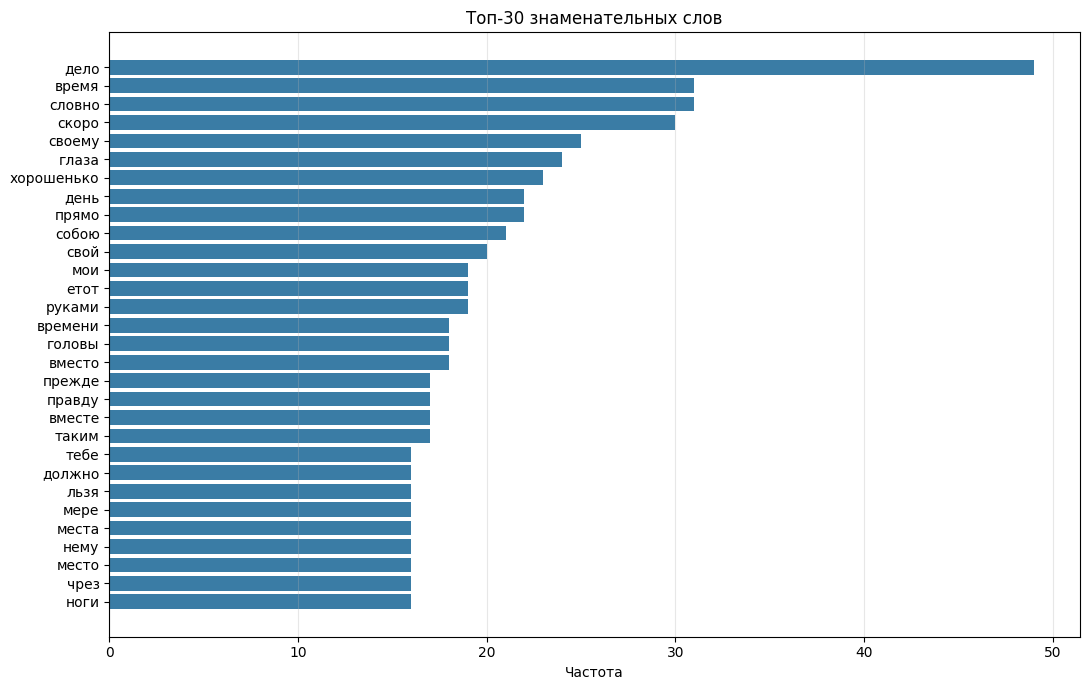

Топ-15: [('дело', 49), ('время', 31), ('словно', 31), ('скоро', 30), ('своему', 25), ('глаза', 24), ('хорошенько', 23), ('день', 22), ('прямо', 22), ('собою', 21), ('свой', 20), ('мои', 19), ('етот', 19), ('руками', 19), ('времени', 18)]


In [8]:
freq = Counter(tokens_clean)
top30 = freq.most_common(30)

fig, ax = plt.subplots(figsize=(11, 7))
words, counts = zip(*top30)
y = np.arange(len(words))
ax.barh(y, counts, color="#3a7ca5")
ax.set_yticks(y); ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Частота")
ax.set_title("Топ-30 знаменательных слов")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Топ-15:", top30[:15])

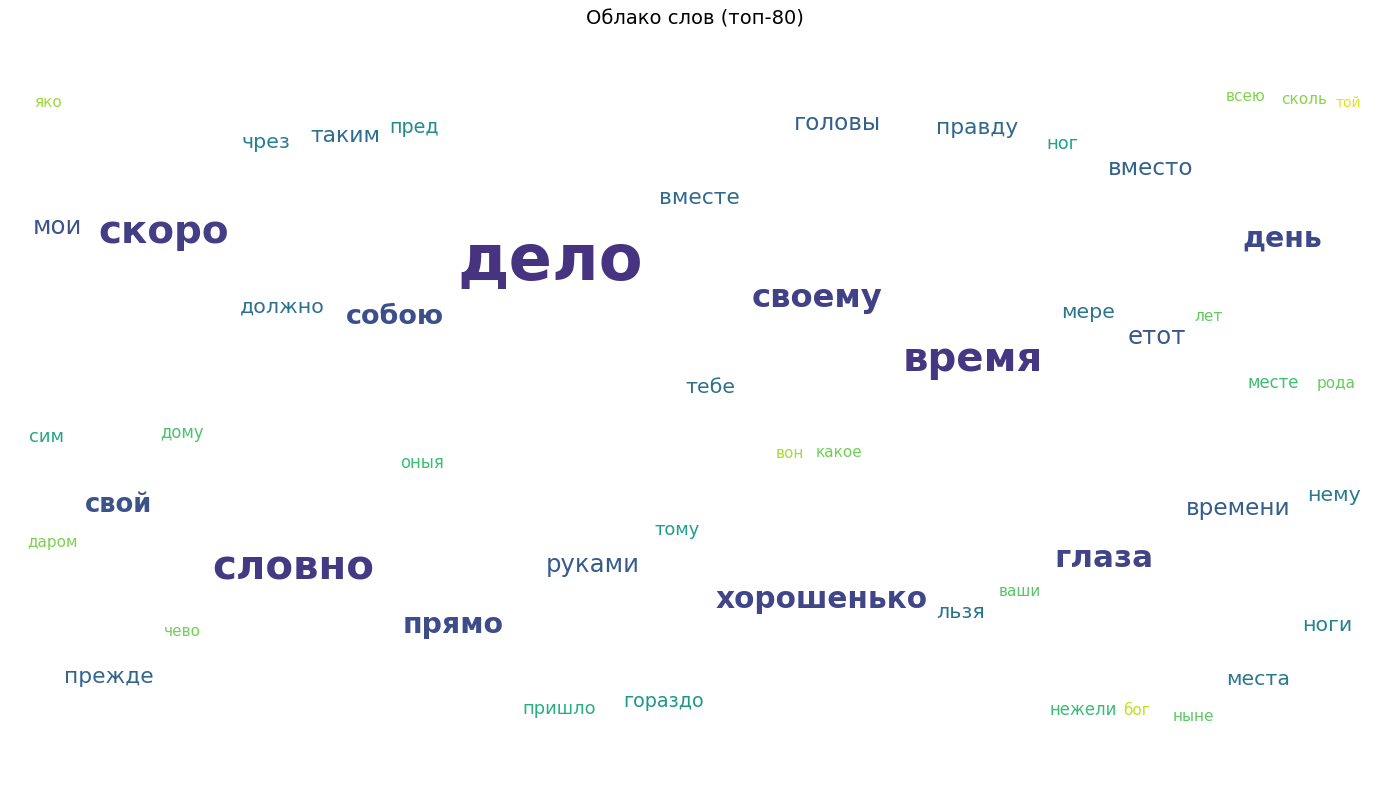

In [9]:
# Облако слов — топ-80
np.random.seed(42)
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 100); ax.set_ylim(0, 60); ax.axis("off")
top80 = freq.most_common(80)
mx, mn = top80[0][1], top80[-1][1]
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(top80)))
placed_boxes = []
for i, (w, c) in enumerate(top80):
    size = 10 + 36 * (c - mn) / max(mx - mn, 1)
    text_w = 0.55 * size * len(w) / 7.5
    text_h = size * 0.7
    for _ in range(300):
        x = np.random.uniform(text_w/2 + 1, 100 - text_w/2 - 1)
        y = np.random.uniform(text_h/2 + 1, 60 - text_h/2 - 1)
        xmin, xmax = x - text_w/2, x + text_w/2
        ymin, ymax = y - text_h/2, y + text_h/2
        if all(xmax < a or xmin > c2 or ymax < b or ymin > d
               for (a, b, c2, d) in placed_boxes):
            placed_boxes.append((xmin, ymin, xmax, ymax))
            ax.text(x, y, w, fontsize=size, color=colors[i],
                    ha="center", va="center",
                    fontweight="bold" if size > 18 else "normal")
            break
ax.set_title("Облако слов (топ-80)", fontsize=14)
plt.tight_layout(); plt.show()

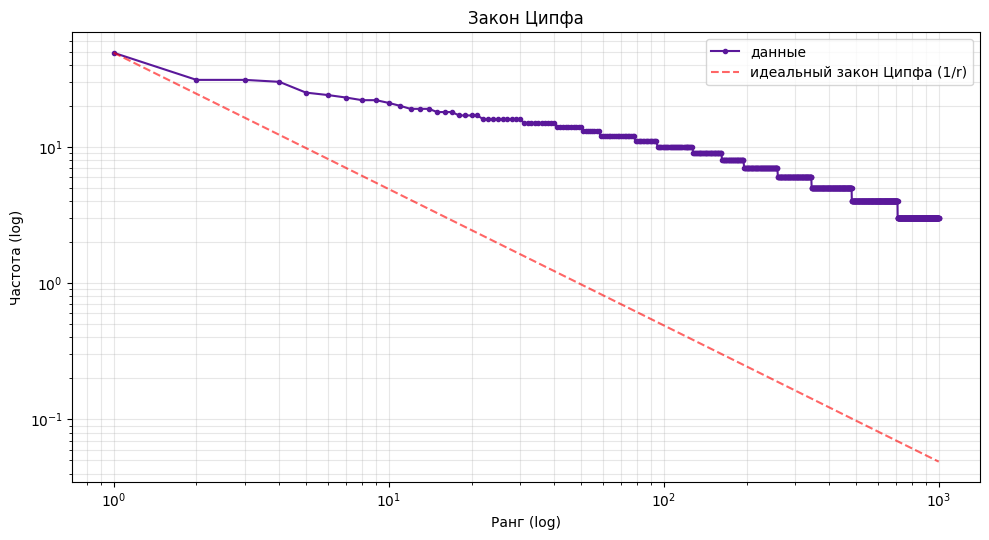

In [10]:
# Закон Ципфа
fig, ax = plt.subplots(figsize=(10, 5.5))
ranks = np.arange(1, 1001)
freqs = sorted(freq.values(), reverse=True)[:1000]
ax.loglog(ranks, freqs, "o-", markersize=3, color="#5a189a", label="данные")
ax.loglog(ranks, freqs[0] / ranks, "--", color="red", alpha=0.6,
          label="идеальный закон Ципфа (1/r)")
ax.set_xlabel("Ранг (log)"); ax.set_ylabel("Частота (log)")
ax.set_title("Закон Ципфа")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

График ранг–частота близок к закону Ципфа — это значит, что текст естественный

## 4. Морфологический анализ

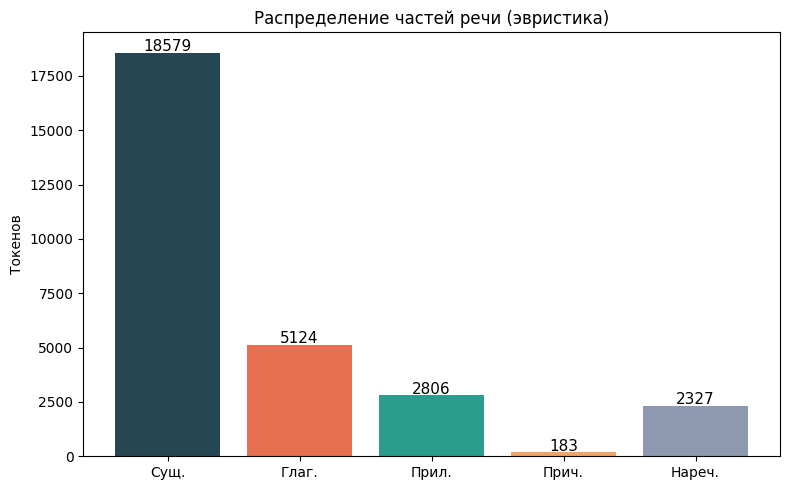

Доли: {'Сущ.': '64.0%', 'Глаг.': '17.7%', 'Прил.': '9.7%', 'Прич.': '0.6%', 'Нареч.': '8.0%'}


In [11]:
def heuristic_pos(w):
    if len(w) < 2: return "OTHER"
    if re.search(r"(ться|тися)$", w): return "VERB_INF"
    if re.search(r"(ть|ти|чь)$", w) and len(w) > 3: return "VERB_INF"
    if re.search(r"(лся|лась|лось|лись)$", w): return "VERB_PAST"
    if re.search(r"(л|ла|ло|ли)$", w) and len(w) > 3: return "VERB_PAST"
    if re.search(r"(ешь|ишь|ете|ите|ем|им|ет|ёт|ит|ут|ют|ат|ят)$", w) and len(w) > 3:
        return "VERB_PRES"
    if re.search(r"(вший|вшая|вшее|вшие|нный|нная|нное|нные|щий|щая|щее|щие|мый|мая|мое|мые)$", w):
        return "PART"
    if re.search(r"(ый|ий|ой|ая|яя|ое|ее|ые|ие|ого|его|ому|ему|ыми|ими|ых|их|ою|ею)$", w) and len(w) > 4:
        return "ADJ"
    if w.endswith(("о", "е")) and len(w) > 4:
        return "ADV"
    return "NOUN"

pos_counts = Counter(heuristic_pos(t) for t in tokens_all if len(t) > 1)
groups = {"Сущ.": pos_counts["NOUN"],
          "Глаг.": pos_counts["VERB_INF"]+pos_counts["VERB_PAST"]+pos_counts["VERB_PRES"],
          "Прил.": pos_counts["ADJ"],
          "Прич.": pos_counts["PART"],
          "Нареч.": pos_counts["ADV"]}

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(groups.keys(), groups.values(),
       color=["#264653", "#e76f51", "#2a9d8f", "#f4a261", "#8d99ae"])
ax.set_title("Распределение частей речи (эвристика)")
ax.set_ylabel("Токенов")
for i, v in enumerate(groups.values()):
    ax.text(i, v + 80, str(v), ha="center", fontsize=11)
plt.tight_layout(); plt.show()
print("Доли:", {k: f"{v/sum(groups.values())*100:.1f}%" for k, v in groups.items()})

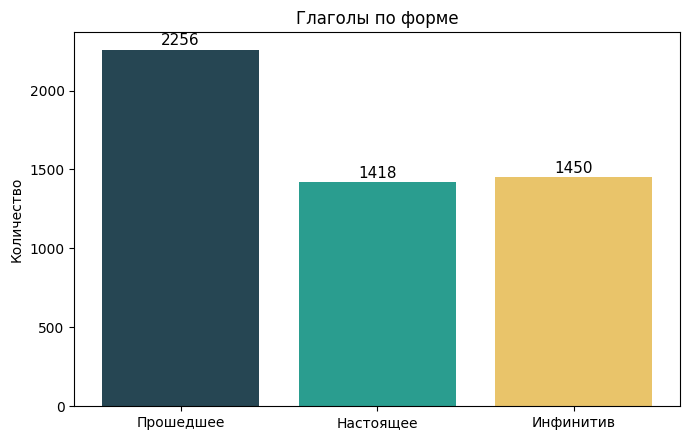

In [12]:
verbs = {"Прошедшее": pos_counts["VERB_PAST"],
         "Настоящее": pos_counts["VERB_PRES"],
         "Инфинитив": pos_counts["VERB_INF"]}
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(verbs.keys(), verbs.values(), color=["#264653", "#2a9d8f", "#e9c46a"])
ax.set_title("Глаголы по форме")
ax.set_ylabel("Количество")
for i, v in enumerate(verbs.values()):
    ax.text(i, v + 30, str(v), ha="center", fontsize=11)
plt.tight_layout(); plt.show()

## 5. Синтаксический уровень: длины предложений

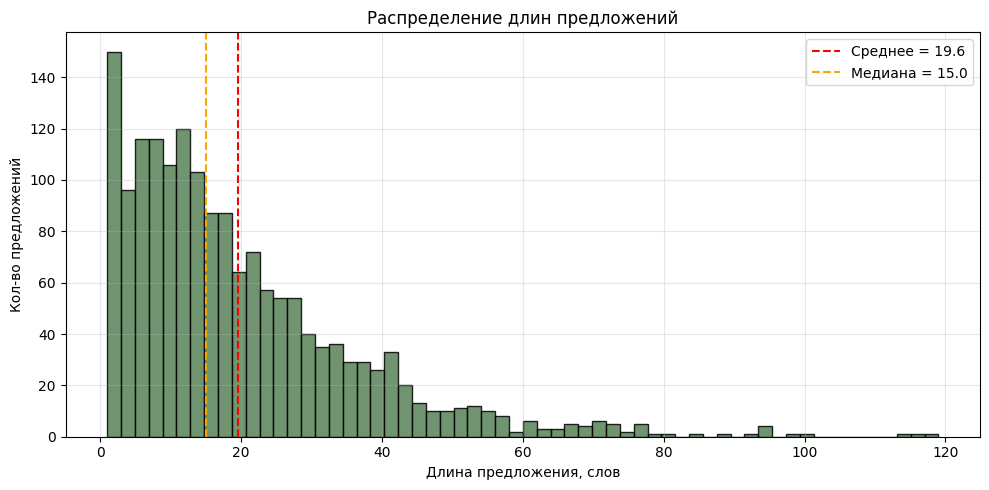

Предложений: 1659; среднее: 19.6; медиана: 15; макс: 119


In [13]:
sentences = re.split(r"[.!?]+", main_text)
sentences = [s.strip() for s in sentences if s.strip()]
sent_lens = [len(re.findall(r"[А-Яа-яёЁ]+", s)) for s in sentences]
sent_lens = [l for l in sent_lens if l > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sent_lens, bins=60, color="#588157", edgecolor="black", alpha=0.85)
ax.axvline(np.mean(sent_lens), color="red", linestyle="--",
           label=f"Среднее = {np.mean(sent_lens):.1f}")
ax.axvline(np.median(sent_lens), color="orange", linestyle="--",
           label=f"Медиана = {np.median(sent_lens):.1f}")
ax.set_xlabel("Длина предложения, слов")
ax.set_ylabel("Кол-во предложений")
ax.set_title("Распределение длин предложений")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Предложений: {len(sent_lens)}; среднее: {np.mean(sent_lens):.1f}; "
      f"медиана: {np.median(sent_lens):.0f}; макс: {max(sent_lens)}")

## 6. TF-IDF по главам

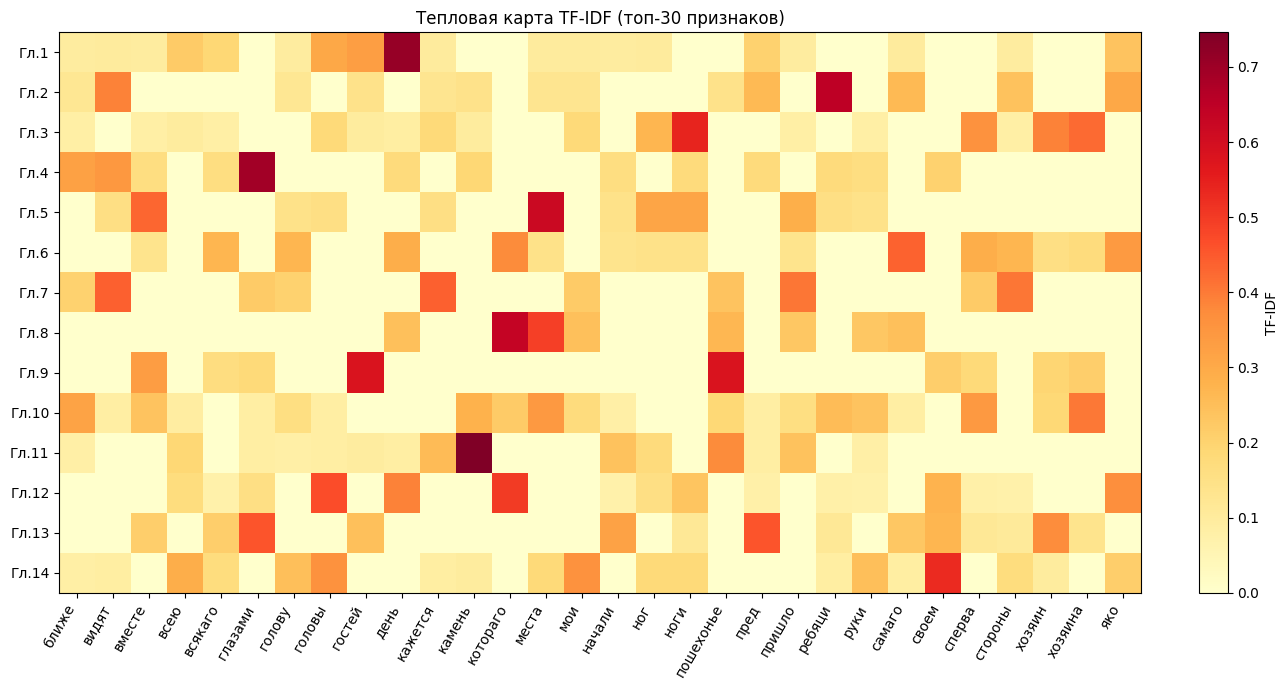

In [14]:
chap_tokens = []
chap_texts = []
for c in chapters:
    toks = tokenize(c)
    toks = [t for t in toks if t not in STOP and len(t) > 2]
    chap_tokens.append(toks)
    chap_texts.append(" ".join(toks))

vectorizer = TfidfVectorizer(max_features=30, min_df=2, max_df=0.6)
X = vectorizer.fit_transform(chap_texts)
features = vectorizer.get_feature_names_out()
tfidf_arr = X.toarray()

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(tfidf_arr, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=60, ha="right")
ax.set_yticks(range(len(chapters)))
ax.set_yticklabels([f"Гл.{i+1}" for i in range(len(chapters))])
ax.set_title("Тепловая карта TF-IDF (топ-30 признаков)")
plt.colorbar(im, ax=ax, fraction=0.025).set_label("TF-IDF")
plt.tight_layout(); plt.show()

In [15]:
print("Топ-3 ключевых слова в каждой главе (по TF-IDF):")
for i in range(len(chapters)):
    row = tfidf_arr[i]
    idxs = np.argsort(row)[::-1][:3]
    print(f"  Гл.{i+1:2d}: {', '.join(features[j] for j in idxs)}")

Топ-3 ключевых слова в каждой главе (по TF-IDF):
  Гл. 1: день, гостей, головы
  Гл. 2: ребяци, видят, яко
  Гл. 3: ноги, хозяина, хозяин
  Гл. 4: глазами, видят, ближе
  Гл. 5: места, вместе, ног
  Гл. 6: самаго, котораго, яко
  Гл. 7: видят, кажется, стороны
  Гл. 8: котораго, места, пошехонье
  Гл. 9: пошехонье, гостей, вместе
  Гл.10: хозяина, сперва, места
  Гл.11: камень, пошехонье, кажется
  Гл.12: котораго, головы, день
  Гл.13: пред, глазами, хозяин
  Гл.14: своем, мои, головы


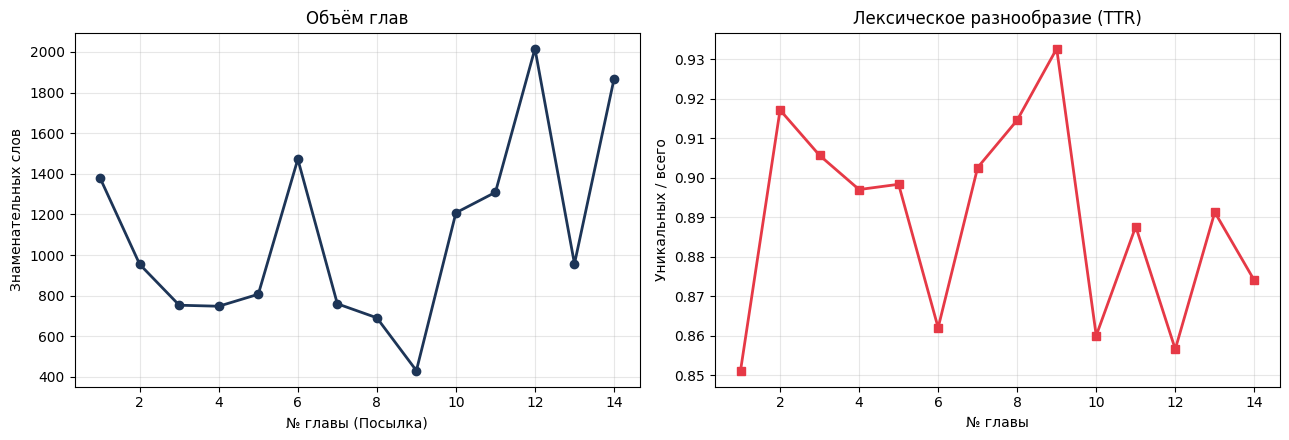

In [16]:
# Динамика глав
chap_word_count = [len(toks) for toks in chap_tokens]
chap_unique = [len(set(toks)) for toks in chap_tokens]
chap_ttr = [u/w if w else 0 for u, w in zip(chap_unique, chap_word_count)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(1, len(chapters)+1), chap_word_count, "o-", color="#1d3557", linewidth=2)
axes[0].set_title("Объём глав")
axes[0].set_xlabel("№ главы (Посылка)")
axes[0].set_ylabel("Знаменательных слов")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(chapters)+1), chap_ttr, "s-", color="#e63946", linewidth=2)
axes[1].set_title("Лексическое разнообразие (TTR)")
axes[1].set_xlabel("№ главы")
axes[1].set_ylabel("Уникальных / всего")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Коллокации и устойчивые сочетания

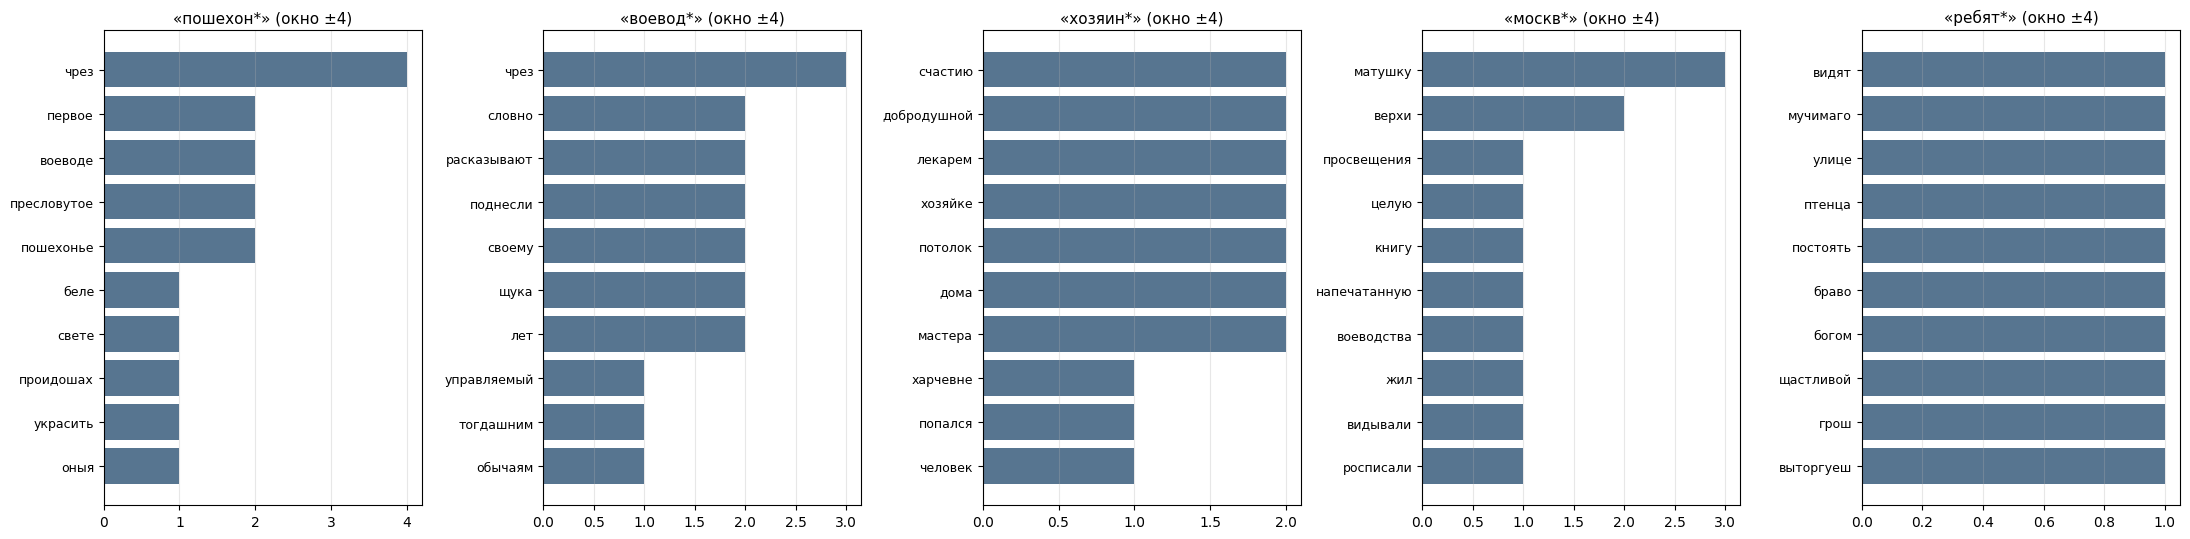

In [17]:
key_concepts = ["пошехон", "воевод", "хозяин", "москв", "ребят"]

def find_collocations(tokens, concept, window=5):
    cols = Counter()
    for i, t in enumerate(tokens):
        if concept in t:
            for j in range(max(0, i-window), min(len(tokens), i+window+1)):
                if j == i: continue
                w = tokens[j]
                if w in STOP or len(w) < 3: continue
                cols[w] += 1
    return cols

fig, axes = plt.subplots(1, len(key_concepts), figsize=(22, 5.5))
for ax, concept in zip(axes, key_concepts):
    cols = find_collocations(tokens_all, concept, window=4)
    top = cols.most_common(10)
    if not top: continue
    words_, counts_ = zip(*top)
    y = np.arange(len(words_))
    ax.barh(y, counts_, color="#577590")
    ax.set_yticks(y); ax.set_yticklabels(words_, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"«{concept}*» (окно ±4)", fontsize=11)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

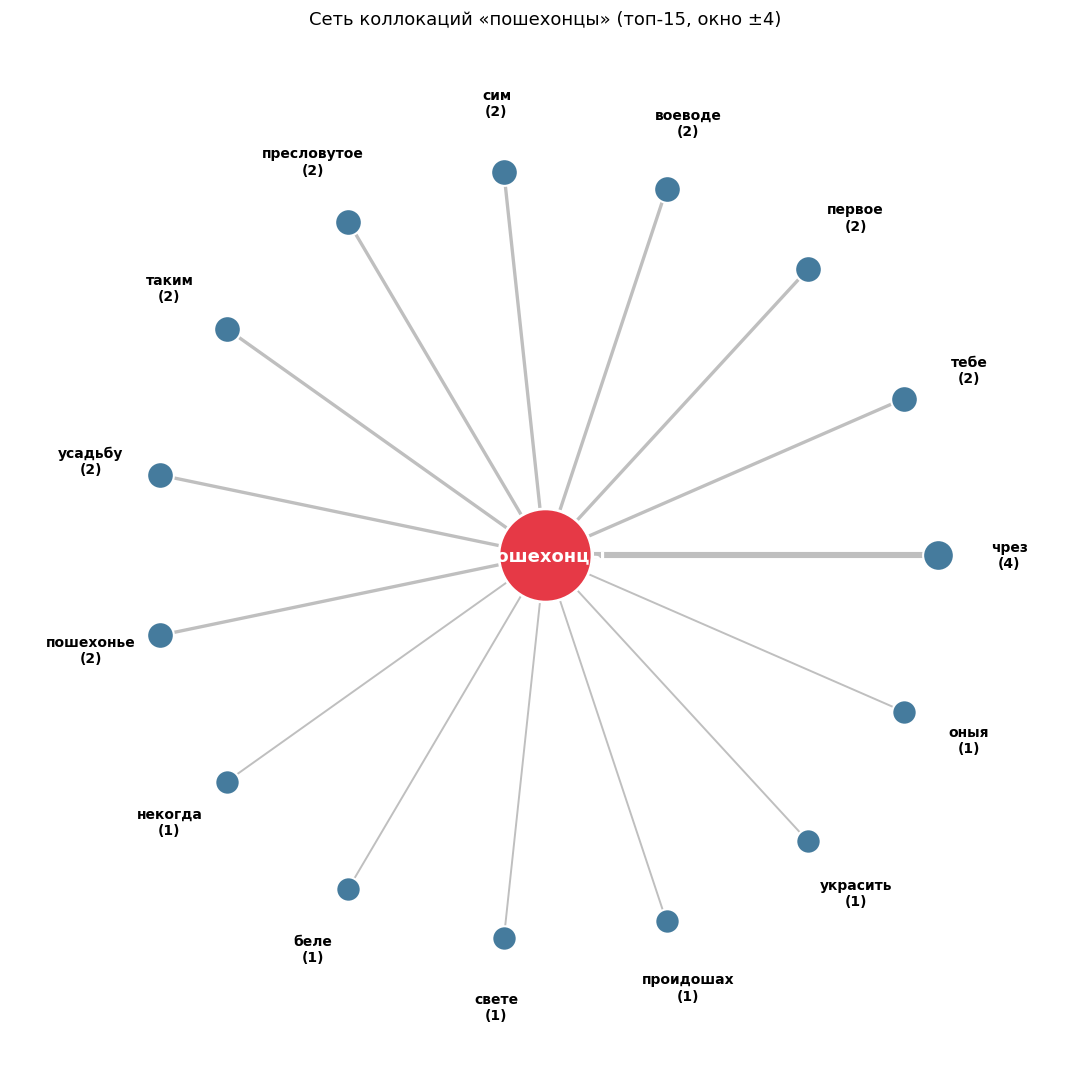

In [18]:
# Сеть коллокаций для главного концепта — пошехонцы
cols = find_collocations(tokens_all, "пошехон", window=5)
top_links = cols.most_common(15)

fig, ax = plt.subplots(figsize=(11, 11))
ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7); ax.axis("off")
n = len(top_links)
ax.scatter(0, 0, s=4500, c="#e63946", zorder=10, edgecolors="white", linewidths=2)
ax.text(0, 0, "пошехонцы", ha="center", va="center", fontsize=13,
        fontweight="bold", color="white", zorder=11)
for i, (w, c) in enumerate(top_links):
    angle = 2 * np.pi * i / n
    x, y = np.cos(angle) * 1.25, np.sin(angle) * 1.25
    width = 0.4 + 4 * c / top_links[0][1]
    ax.plot([0, x], [0, y], color="gray", linewidth=width, alpha=0.5, zorder=1)
    ax.scatter(x, y, s=250 + 60 * c, c="#457b9d", zorder=5,
               edgecolors="white", linewidths=1.5)
    ax.text(x*1.18, y*1.18, f"{w}\n({c})", ha="center", va="center",
            fontsize=10, fontweight="bold")
ax.set_title("Сеть коллокаций «пошехонцы» (топ-15, окно ±4)", fontsize=13)
plt.tight_layout(); plt.show()

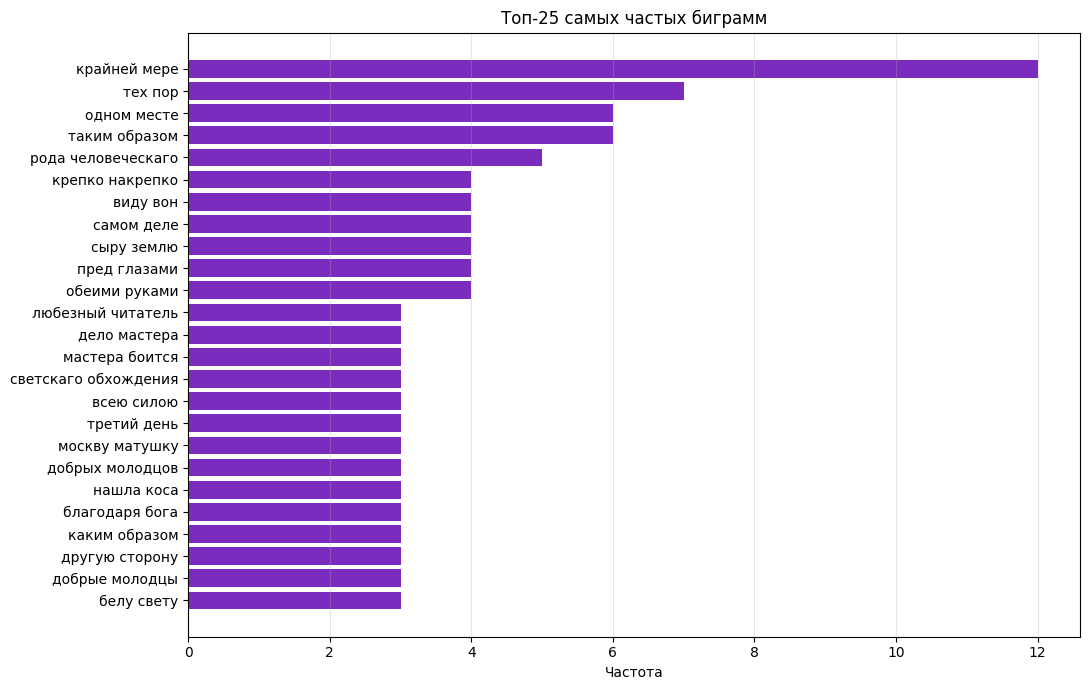

In [19]:
# Биграммы
bigrams = Counter()
for i in range(len(tokens_all) - 1):
    a, b = tokens_all[i], tokens_all[i+1]
    if a in STOP or b in STOP or len(a) < 3 or len(b) < 3:
        continue
    bigrams[(a, b)] += 1

top_bigrams = bigrams.most_common(25)
fig, ax = plt.subplots(figsize=(11, 7))
labels = [f"{a} {b}" for (a, b), _ in top_bigrams]
counts_b = [c for _, c in top_bigrams]
y = np.arange(len(labels))
ax.barh(y, counts_b, color="#7b2cbf")
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Частота")
ax.set_title("Топ-25 самых частых биграмм")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

Топ-25 биграмм — прямой и однозначный отпечаток русской фольклорно-сказовой стилистики XVIII–XIX вв.

## 8. Антропонимы и топонимы

In [20]:
proper_pattern = re.compile(r"(?<=[а-яё ,;:])\s+([А-ЯЁ][а-яё]{2,})")
proper_names = Counter()
for m in proper_pattern.finditer(text_modern):
    name = m.group(1)
    proper_names[name] += 1

# Уберём глобально частотные «обычные» слова с большой буквы в начале предложений
# Эвристика: пропускаем те, что при нижнем регистре есть в массовых словах
common = {w for w, c in freq.items() if c > 5}
suspicious = [(n, c) for n, c in proper_names.items() if c >= 2 and n.lower() not in common]
print("Топ-20 потенциальных собственных имён:")
for n, c in sorted(suspicious, key=lambda x: -x[1])[:20]:
    print(f"  {n}: {c}")

Топ-20 потенциальных собственных имён:
  Пошехонцах: 7
  Пошехонцев: 5
  Пугниево: 5
  Микеху: 5
  Трифоныца: 5
  Пошехонцам: 4
  Пошехонцами: 4
  Руских: 4
  Богу: 4
  Царь: 4
  Филатьевна: 4
  Ирои: 4
  Нечистаго: 4
  Тарас: 3
  Гольтяпон: 3
  Медведя: 3
  Теперь: 3
  Вот: 3
  Выборной: 3
  Соцкой: 3


## 9. Замечание о диалектной речи

In [21]:
dialect_markers = re.compile(
    r"^(сц|ац|оц|ец|иц|уц|ыц|сы|ц[а-я]|ентакъ|ента|"
    r"іо|іон|іона|іом|іомъ|іому|акъ|оцъ|ноіо)"
    r"|(цъ|сь|ця|цы|цѣ)$"
)
dialect_tokens = [t for t in tokens_all
                  if re.search(r"ц[аяeиыо]", t) and "це" not in t
                     and t not in STOP and len(t) > 3]
n_dialect = sum(1 for t in tokens_all if "сц" in t or "цы" in t and len(t) > 4)
print(f"Слов, содержащих характерные диалектные сочетания: {n_dialect}")
print(f"Доля: {n_dialect/len(tokens_all)*100:.2f}%")
print("Примеры:", [t for t in tokens_all if "сц" in t][:15])

Слов, содержащих характерные диалектные сочетания: 127
Доля: 0.39%
Примеры: ['исцеляете', 'дароносцы', 'сцене', 'сцо', 'сцо', 'сцо', 'сцо', 'сцуку', 'сцукою', 'сцуцыны', 'сцоб', 'сцо', 'есцо', 'сциуры', 'сцо']


## 10. Реконструкция и интерпретация

| Параметр | Значение |
|---|---|
| Объём | ~32 500 словоформ, ~205 000 знаков |
| Структура | посвящение → оглавление → эпистолярное предисловие («Любовед к Словохоту») → 16 «Посылок» → итог |
| Орфография | дореформенная (ѣ, і, ѳ, ъ) |
| Главные персонажи | Пошехонцы (собирательное), Воевода, Любовѣдъ, Словохотъ |
| Антропонимы | говорящие фамилии и просторечные имена в духе классицистической комедии |
| Топонимы | Пошехонье, Москва, плюс комические вымышленные деревни |
| Стилистика | сказово-фольклорные формулы + риторика позднего классицизма |
| Регистр | смесь «высокого» авторского слога и «низкой» прямой речи с цоканьем |

### Жанр

Это сборник прозаических плутовских/глуповских анекдотов, оформленный как переписка двух любителей старины. На современном языке это можно назвать новеллами-анекдотами о простаках, в духе западной традиции «о шильдбюргерах» / «глупцах из Готама», но в сугубо русском оформлении.

### Эпоха

Все стилистические признаки указывают на первую четверть XIX века (примерно 1810–1825 гг.) возможно, чуть раньше.
Датировка: примерно 1815–1825 гг.

### Тематика и сюжет

Текст принадлежит к давней народной традиции «пошехонских анекдотов»

### Стиль и интонация

Эмоциональный тон — добродушно-насмешливый, иногда поучительный (короткие нравоучительные вставки, например про вред пьянства в гл. 14).

### Языковые особенности, подтверждающие выводы

| Признак | Что подтверждает |
|---|---|
| Дореф. орфография | дата ≤ 1918 |
| Упоминание Александра I и войны 1812 | дата ≈ 1815–1825 |
| «Добрые молодцы», «сыру землю», «бѣлу свѣту», «крѣпко накрѣпко» | сказово-фольклорный регистр |
| Длинные риторические периоды + латинские цитаты | классицистическая выучка автора |
| Цоканье в прямой речи («сцо», «цортъ», «цисе») | стилизация под северный (ярославский) диалект |
| Имена типа Любовѣд, Словохот, Скотинин, Толстолобов | «говорящие» имена в духе Сумарокова, Фонвизина, Новикова |
| Эпистолярная рамка с «Посылками» | модный приём конца XVIII — нач. XIX в. |

### Гипотеза о произведении

Совокупность признаков указывает на «Анекдоты древних пошехонцев» В. С. Берёзайского.